## 1. Import Libraries & modules

In [1]:
import pandas as pd
import itertools
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.model_selection import train_test_split
import numpy as np
import matplotlib.pyplot as plt
import xgboost as xgb
from lightgbm import LGBMClassifier
import os
import seaborn as sns
from wordcloud import WordCloud

## 2. Import & Explore Data

In [2]:
df = pd.read_csv("malicious_url.csv")

print("Dataframe shape: ", df.shape, "\n")
print("Types or url: ", df.type.value_counts())

df.head()

Dataframe shape:  (651191, 2) 

Types or url:  type
benign        428103
defacement     96457
phishing       94111
malware        32520
Name: count, dtype: int64


,url,type
0,br-icloud.com.br,phishing
1,mp3raid.com/music/krizz_kaliko.html,benign
2,bopsecrets.org/rexroth/cr/1.htm,benign
3,http://www.garage-pirenne.be/index.php?option=...,defacement
4,http://adventure-nicaragua.net/index.php?optio...,defacement


**Plotting Wordcloud**

In [3]:
# Create dataframes for each type of URL
df_benign = df[df.type == 'benign']
df_defacement = df[df.type == 'defacement']
df_phishing = df[df.type == 'phishing']
df_malware = df[df.type == 'malware']

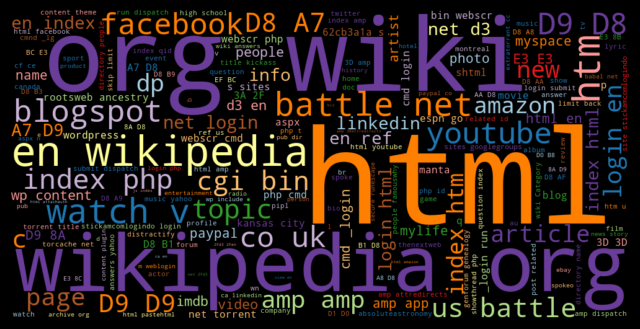

In [4]:
# WordCloud for benign
benign_url = ' '.join(i for i in df_benign.url)
wordcloud = WordCloud(width=1000, height=500, colormap='Paired').generate(benign_url)
plt.figure(figsize=(8, 5), facecolor='k')
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.show()

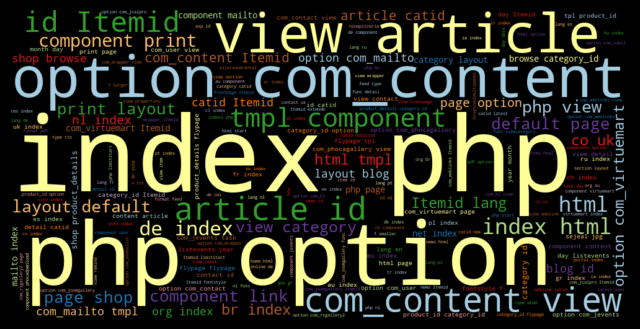

In [5]:
# WordCloud for defacement
defacement_url = ' '.join(i for i in df_defacement.url)
wordcloud = WordCloud(width=1000, height=500, colormap='Paired').generate(defacement_url)
plt.figure(figsize=(8, 5), facecolor='k')
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.show()

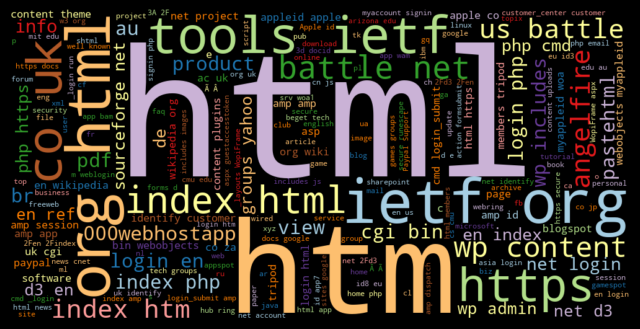

In [6]:
# WordCloud for phishing
phishing_url = ' '.join(i for i in df_phishing.url)
wordcloud = WordCloud(width=1000, height=500, colormap='Paired').generate(phishing_url)
plt.figure(figsize=(8, 5), facecolor='k')
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.show()

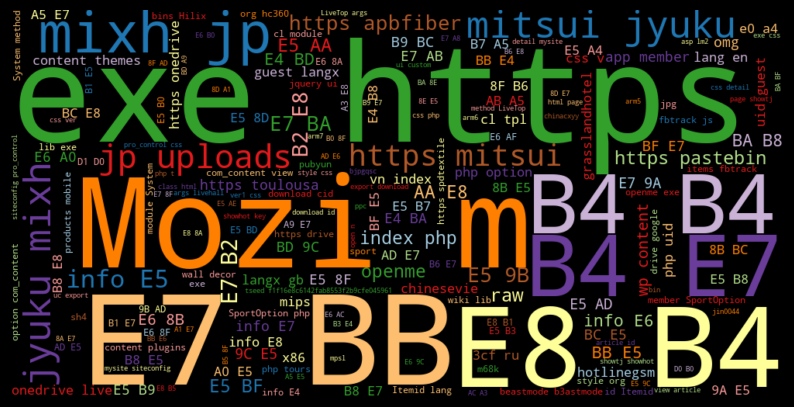

In [7]:
# WordCloud for malware
malware_url = ' '.join(i for i in df_malware.url)
wordcloud = WordCloud(width=1000, height=500, colormap='Paired').generate(malware_url)
plt.figure(figsize=(10, 6), facecolor='k')
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.show()

**Feature Engineering**

In [8]:
import ipaddress
from urllib.parse import urlparse

def have_ip(url):
    try:
        host = urlparse(url).hostname  # lấy phần host
        if host is None:
            return 0
        
        # bỏ ngoặc vuông nếu là IPv6
        host = host.strip("[]")
        
        ipaddress.ip_address(host)  # thử parse
        return 1
    except ValueError:
        return 0
    
df['use_of_ip'] = df['url'].apply(lambda i: have_ip(i))

In [9]:
import re
def abnormal_url(url):
    hostname = urlparse(url).hostname
    hostname = str(hostname)
    match = re.search(hostname, url)
    if match:
        return 1
    else:
        return 0
    
df['abnormal_url'] = df['url'].apply(lambda i: abnormal_url(i))    

In [10]:
from googlesearch import search

def google_index(url):
    site = search(url, 5)
    return 1 if site else 0

df['google_index'] = df['url'].apply(lambda i: google_index(i))

def count_dot(url):
    count_dot = url.count('.')
    return count_dot

df['Count_dot'] = df['url'].apply(lambda i: count_dot(i))

In [11]:
df.head()

,url,type,use_of_ip,abnormal_url,google_index,Count_dot
0,br-icloud.com.br,phishing,0,0,1,2
1,mp3raid.com/music/krizz_kaliko.html,benign,0,0,1,2
2,bopsecrets.org/rexroth/cr/1.htm,benign,0,0,1,2
3,http://www.garage-pirenne.be/index.php?option=...,defacement,0,1,1,3
4,http://adventure-nicaragua.net/index.php?optio...,defacement,0,1,1,2
